In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
import matplotlib

In [2]:
def get_var_size():
    # Get all variables in the current namespace
    variables = {name: value for name, value in globals().items() if not name.startswith("__")}

    # Sort variables by size
    sorted_vars = sorted(variables.items(), key=lambda x: sys.getsizeof(x[1]), reverse=True)

    # Print variable sizes
    for name, value in sorted_vars:
        print(f"{name}: {sys.getsizeof(value) / 1024:.2f} KB")

In [3]:
fly_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}'
filter_name = 'functional_channel_2_moco_warp_blurred_hpf_dff_filtered_total.h5'
STA_path = os.path.join(fly_path, 'temp_filter', filter_name)
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'


# Move all the temp_filter data to one folder for ease of access
### this is probs not necessary

In [9]:
%%time
fly_list=[226,227,228,234,239,240,241,242,249,250] #choose flies off which to create the supervox mask--try using all

step_size=100
for fly in fly_list:
    fly_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly}'
    files = os.listdir(os.path.join(fly_path, 'temp_filter'))
    file = f"functional_channel_2_moco_warp_blurred_hpf_dff_filtered_total.h5"
    if file in files:
        source = os.path.join(fly_path, 'temp_filter', file)
        new_file = f"{fly}_tf_total.h5"
    #         print(new_file)
        destination = os.path.join(later_dir, new_file)
        if os.path.exists(destination)==False: 
            dest = shutil.copyfile(source, destination)
            print("Destination path:", destination)

    else:
        print("Not there yet!")
    

Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/226_tf_total.h5
CPU times: user 8.56 s, sys: 49.3 s, total: 57.8 s
Wall time: 2min 8s


In [5]:
fly_list

[226, 227, 228, 234, 239, 240, 241, 242, 249, 250]

# Combine flies into one big ass brain
### I tried interleaving and just concatenating I think either works but this just scratched that itch in my brain
### this is the longest step in the process, can take upwards of 30mins lol

In [10]:
%%time
####INTERLEAVE the filtered voxels--there might be an easier way to do this or that it's not necessary but 
# idk what that is. Feel free to find your own way.
nx,ny,nz,nt=314,146, 91, 1100
# nt is a value based of the largest of my tf files last dimmension. I wasn't sure how best to establish so 
# i hard coded here. I know, bad practice.
final_nt=len(fly_list) * nt
interleaved = np.empty((nx * ny * nz, final_nt), dtype=np.float32)
print(f"inter shape is {np.shape(interleaved)}")
for i, fly in enumerate(fly_list):
    print(fly)
    file_name = f"{fly}_tf_total.h5"
    tf_path = os.path.join(later_dir,file_name)
    if os.path.exists(tf_path):
        with h5py.File(tf_path, 'r') as hf:
                brain = hf['brain'][:]
                dimsb = np.shape(brain)
                print(f"Brain shape is {dimsb}")
                padded_matrix = np.pad(brain, ((0, 0), (0, 0), (0, 0), (0, nt - dimsb[-1])), mode='constant', constant_values=np.nan)
                reshaped_matrix = padded_matrix.reshape(nx * ny * nz, nt)
                interleaved[:, i::len(fly_list)] = reshaped_matrix
interleaved_4d = interleaved.reshape(nx, ny, nz, final_nt)
print(np.shape(interleaved_4d))

inter shape is (4171804, 11000)
226
Brain shape is (314, 146, 91, 1030)
227
Brain shape is (314, 146, 91, 1030)
228
Brain shape is (314, 146, 91, 1030)
234
Brain shape is (314, 146, 91, 1030)
239
Brain shape is (314, 146, 91, 1035)
240
Brain shape is (314, 146, 91, 1039)
241
Brain shape is (314, 146, 91, 1035)
242
Brain shape is (314, 146, 91, 1030)
249
Brain shape is (314, 146, 91, 1035)
250
Brain shape is (314, 146, 91, 1035)
(314, 146, 91, 11000)
CPU times: user 5min 19s, sys: 6min 52s, total: 12min 11s
Wall time: 17min 17s


# Save the giant brain
### For use later. Since it's such a pain to make

In [11]:
%%time
save_file=os.path.join(later_dir, "10flies_giant_tf.npy")
with h5py.File(save_file, "w") as data_file:
    data_file.create_dataset("data", data=interleaved_4d.astype('float32'))

# Load the brain if you've already created it

In [ ]:
# %% time
# load_file=os.path.join(later_dir, "10flies_giant_tf.npy")
# with h5py.File(load_file, 'r') as hf:
#     interleaved_4d = hf['data'][:]
#     dimsb = np.shape(interleaved_4d)
#     print(f"Brain shape is {dimsb}")

# Get rid of nans or infs

In [14]:
%%time
# there were some weird values in my brains (probs just imaging bugs). I tried nan_to_num to get rid of those
# vals but it was too time intensive so this essentially removes them

interleaved_4d[np.isnan(interleaved_4d)] = 0
interleaved_4d[np.isinf(interleaved_4d)] = 5

CPU times: user 1min 19s, sys: 45.9 s, total: 2min 5s
Wall time: 2min 5s


In [ ]:
# %%time
### Here's as mentioned above
# save_file=os.path.join(later_dir, "10flies_giant_tf.npy")
# dims=np.shape(interleaved_4d)
# steps=1000
# with h5py.File(save_file, 'w') as f:
# #     f.create_dataset('dims', data=dims)
#     dset = f.create_dataset('data', dims, dtype='float32', chunks=True)
    
#     for i in range(0,dims[-1],steps):
#         end = i + steps if i + steps < dims[-1] else dims[-1]
#         print(i, end)
#         f['data'][:,:,:,i:end] = np.nan_to_num(interleaved_4d[...,i:end])

# Make the mask
### The mask for the supervoxels needs to maintain nz dim and nt dim which the loop does

In [ ]:
%%time
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
cluster_dir = os.path.join(later_dir, 'clustering')
if not os.path.exists(cluster_dir):
    os.mkdir(cluster_dir)
n_clusters = 2000
brain=interleaved_4d
shape=np.shape(brain)
connectivity = grid_to_graph(shape[0],shape[1])
cluster_labels = []
t_shape = shape[3]
for z in range(shape[2]):
    neural_activity = brain[:,:,z,:].reshape(-1, t_shape)
    cluster_model = AgglomerativeClustering(n_clusters=n_clusters,
                                memory=cluster_dir,
                                linkage='ward',
                                connectivity=connectivity)
    cluster_model.fit(neural_activity)
    cluster_labels.append(cluster_model.labels_)
cluster_labels = np.asarray(cluster_labels)

In [ ]:
cluster_labels = np.asarray(cluster_labels)
save_file = os.path.join(cluster_dir, '10flies_cluster_labels_best_flies.npy')
np.save(save_file,cluster_labels)
print(np.shape(cluster_labels))

# Check to see the clusters look good

In [16]:
rainbow_color=np.asarray(['#FFFFFF','#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93','#6d0d25']) #,  '#6d0d25'
# cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'cmap', rainbow_color)
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

In [26]:
cluster_labels_anat=cluster_labels.reshape(91,314,146,)

(-0.5, 313.5, 145.5, -0.5)

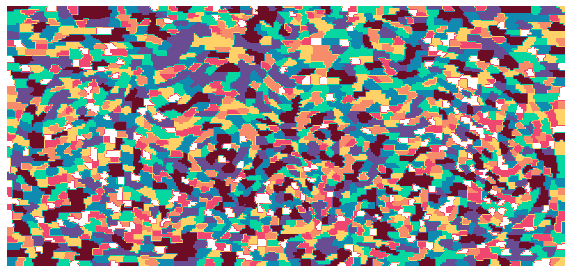

In [28]:
z=33
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(cluster_labels_anat[z].T, cmap=cmap_rainbow)
plt.axis('off')

### If you're interested in looking at the supervoxels on the giant brain you can do that here

In [15]:
%%time
all_signals = []
for z in range(shape[2]):
    neural_activity = brain[:,:,z,:].reshape(-1, t_shape)
    signals = []
    for cluster_num in range(n_clusters):
        cluster_indicies = np.where(cluster_labels[z,:]==cluster_num)[0]
        mean_signal = np.mean(neural_activity[cluster_indicies,:], axis=0)
        signals.append(mean_signal)
    signals = np.asarray(signals)
    all_signals.append(signals)
all_signals = np.asarray(all_signals)

CPU times: user 1min, sys: 28.5 s, total: 1min 29s
Wall time: 1min 29s


In [29]:
all_signals.shape

(91, 2000, 11000)

In [ ]:
%%time
n_clust=2000
supervox_brain=all_signals
full_res_brain=brainsss.supervoxel_to_full_res(supervox_brain, cluster_labels, n_clust)
# full_res_brain=np.moveaxis(full_res_brain, 0,-1)
# full_res_brain=np.moveaxis(full_res_brain, 0,-1)
full_res=np.asarray(full_res_brain)